<img src="images/18.png" width="40%">

<img src="images/19.png" width="40%">

<img src="images/20.png" width="40%">

<img src="images/21.png" width="40%">

<img src="images/22.png" width="40%">

using device: cuda


100%|█████████████████████████████████████████████████████████████████████████████| 26.4M/26.4M [00:25<00:00, 1.04MB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 67.5kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 4.42M/4.42M [00:05<00:00, 758kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 1.23MB/s]


Epoch [1/20] | train_loss:0.7601 | test_loss:0.4982 | test_acc:0.8130
Epoch [2/20] | train_loss:0.4762 | test_loss:0.4414 | test_acc:0.8365
Epoch [3/20] | train_loss:0.4275 | test_loss:0.4124 | test_acc:0.8505
Epoch [4/20] | train_loss:0.3958 | test_loss:0.3963 | test_acc:0.8542
Epoch [5/20] | train_loss:0.3748 | test_loss:0.3820 | test_acc:0.8586
Epoch [6/20] | train_loss:0.3560 | test_loss:0.3661 | test_acc:0.8672
Epoch [7/20] | train_loss:0.3413 | test_loss:0.3574 | test_acc:0.8699
Epoch [8/20] | train_loss:0.3321 | test_loss:0.3492 | test_acc:0.8719
Epoch [9/20] | train_loss:0.3192 | test_loss:0.3455 | test_acc:0.8741
Epoch [10/20] | train_loss:0.3098 | test_loss:0.3466 | test_acc:0.8728
Epoch [11/20] | train_loss:0.3012 | test_loss:0.3389 | test_acc:0.8758
Epoch [12/20] | train_loss:0.2912 | test_loss:0.3323 | test_acc:0.8792
Epoch [13/20] | train_loss:0.2829 | test_loss:0.3246 | test_acc:0.8819
Epoch [14/20] | train_loss:0.2781 | test_loss:0.3267 | test_acc:0.8831
Epoch [15/20] |

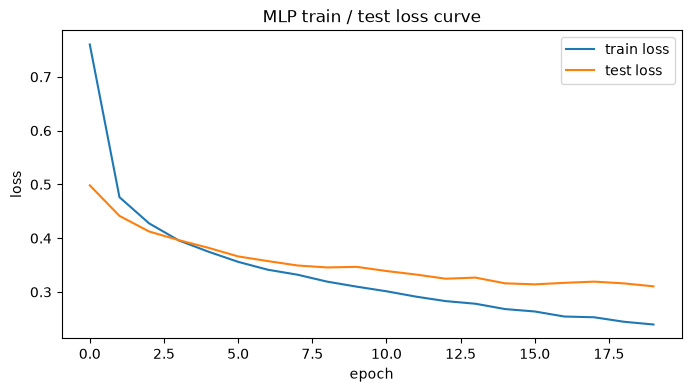

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# -------------------------- 1. 设备配置 --------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")

# -------------------------- 2. 数据集准备 Fashion‑MNIST --------------------------
# 28*28灰度图片，共10类服饰；输入摊平为784维向量
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# -------------------------- 3. 定义多层感知机 MLP --------------------------
class MLP(nn.Module):
    def __init__(self, in_dim=784, hidden_dim1=256, hidden_dim2=128, out_dim=10, dropout_rate=0.2):
        super().__init__()
        # 多层全连接网络
        self.fc1 = nn.Linear(in_dim, hidden_dim1)
        self.act1 = nn.GELU()   # nanoGPT 使用GELU；也可以换成 nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.act2 = nn.GELU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(hidden_dim2, out_dim)

    def forward(self, x):
        # x: [B, 1, 28, 28]
        B = x.shape[0]
        x = x.view(B, -1)   # 摊平图像 [B,784]

        x = self.fc1(x)
        x = self.act1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.act2(x)
        x = self.dropout2(x)

        logits = self.fc3(x)   # 输出logits，不做softmax，交给cross_entropy
        return logits

# 初始化模型
model = MLP().to(device)

# -------------------------- 4. 损失函数、优化器 --------------------------
criterion = nn.CrossEntropyLoss()   # 多分类，内部自带softmax
optimizer = optim.Adam(model.parameters(), lr=3e-4)

# -------------------------- 5. 训练 + 评估循环 --------------------------
epochs = 20
train_loss_history = []
test_loss_history = []

for epoch in range(epochs):
    # ========== 训练阶段 ==========
    model.train()
    total_train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        # backward + update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # ========== 验证阶段 model.eval()，关闭dropout ==========
    model.eval()
    total_test_loss = 0.0
    correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            total_test_loss += loss.item()

            pred = torch.argmax(logits, dim=-1)
            correct += (pred == labels).sum().item()

    avg_test_loss = total_test_loss / len(test_loader)
    test_loss_history.append(avg_test_loss)
    test_acc = correct / len(test_dataset)

    print(f"Epoch [{epoch+1}/{epochs}] | train_loss:{avg_train_loss:.4f} | test_loss:{avg_test_loss:.4f} | test_acc:{test_acc:.4f}")

# -------------------------- 6. 绘制损失曲线（观察过拟合） --------------------------
plt.figure(figsize=(8,4))
plt.plot(train_loss_history, label="train loss")
plt.plot(test_loss_history, label="test loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("MLP train / test loss curve")
plt.show()
